In [4]:
import os
import glob
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
)
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [5]:
class LSTMEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout=0.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

    def forward(self, x):
        _, (hidden, cell) = self.lstm(x)
        return hidden, cell


class LSTMDecoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers, dropout=0.0):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.output_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, hidden, cell):
        output, _ = self.lstm(x, (hidden, cell))
        reconstruction = self.output_layer(output)
        return reconstruction


class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim, num_layers, dropout=0.0):
        super().__init__()
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.encoder = LSTMEncoder(input_dim, hidden_dim, num_layers, dropout)
        self.decoder = LSTMDecoder(latent_dim, hidden_dim, input_dim, num_layers, dropout)
        self.hidden_to_latent = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        hidden, cell = self.encoder(x)
        latent = self.hidden_to_latent(hidden[-1])
        decoder_input = latent.unsqueeze(1).repeat(1, seq_len, 1)
        reconstruction = self.decoder(decoder_input, hidden, cell)
        return reconstruction, latent


print("Model class defined.")

Model class defined.


In [6]:
CHECKPOINT_PATH = "lstm_autoencoder_checkpoint.pth"

checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)

# Ambil hyperparameters & config dari checkpoint
hp = checkpoint["hyperparams"]
FEATURE_COLUMNS = checkpoint["feature_columns"]
scaler = checkpoint["scaler"]
THRESHOLD = checkpoint["threshold"]  # Gunakan optimal threshold
SEQ_LEN = hp["seq_len"]
BATCH_SIZE = hp["batch_size"]

# Rebuild model
model = LSTMAutoencoder(
    input_dim=hp["input_dim"],
    hidden_dim=hp["hidden_dim"],
    latent_dim=hp["latent_dim"],
    num_layers=hp["num_layers"],
    dropout=hp["dropout"],
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("✓ Model loaded successfully")
print(f"\nHyperparameters: {hp}")
print(f"Feature columns: {FEATURE_COLUMNS}")
print(f"Optimal threshold: {THRESHOLD:.6f}")
print(f"Sequence length: {SEQ_LEN}")
print(f"\nModel architecture:\n{model}")

✓ Model loaded successfully

Hyperparameters: {'input_dim': 10, 'hidden_dim': 64, 'latent_dim': 32, 'num_layers': 2, 'dropout': 0.1, 'seq_len': 10, 'batch_size': 256, 'learning_rate': 0.001, 'num_epochs': 30}
Feature columns: ['Dst Port', 'Fwd Pkt Len Min', 'Flow Pkts/s', 'Bwd Pkts/s', 'Fwd IAT Min', 'ECE Flag Cnt', 'ACK Flag Cnt', 'Fwd Seg Size Min', 'Fwd Act Data Pkts', 'Idle Std']
Optimal threshold: 0.527213
Sequence length: 10

Model architecture:
LSTMAutoencoder(
  (encoder): LSTMEncoder(
    (lstm): LSTM(10, 64, num_layers=2, batch_first=True, dropout=0.1)
  )
  (decoder): LSTMDecoder(
    (lstm): LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.1)
    (output_layer): Linear(in_features=64, out_features=10, bias=True)
  )
  (hidden_to_latent): Linear(in_features=64, out_features=32, bias=True)
)


## 4. Fungsi Helper: Preprocessing & Evaluasi per File

In [7]:
def load_and_preprocess(csv_path, feature_columns, scaler):
    """Load CSV, select columns, clean, scale, return arrays + labels."""
    cols_to_load = feature_columns + ["Label"]
    df = pd.read_csv(csv_path, usecols=cols_to_load, low_memory=False)

    # Konversi ke numerik
    for col in feature_columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Hapus Inf dan NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    rows_before = len(df)
    df.dropna(subset=feature_columns, inplace=True)
    rows_after = len(df)

    # Strip whitespace dari label
    df["Label"] = df["Label"].astype(str).str.strip()

    # Label biner: 0 = Benign, 1 = Attack
    labels = (df["Label"] != "Benign").astype(int).values
    label_detail = df["Label"].value_counts()

    # Scale features
    X = scaler.transform(df[feature_columns].values).astype(np.float32)

    return X, labels, label_detail, rows_before, rows_after


def create_sequences_with_labels(data, labels, seq_len):
    """Buat non-overlapping sequences + label per window."""
    sequences, seq_labels = [], []
    for i in range(0, len(data) - seq_len + 1, seq_len):
        sequences.append(data[i : i + seq_len])
        seq_labels.append(1 if labels[i : i + seq_len].sum() > 0 else 0)
    return np.array(sequences), np.array(seq_labels)


@torch.no_grad()
def compute_reconstruction_errors(model, loader, device):
    """Hitung MSE per-sample."""
    model.eval()
    errors = []
    for batch_x, _ in loader:
        batch_x = batch_x.to(device)
        recon, _ = model(batch_x)
        mse = ((batch_x - recon) ** 2).mean(dim=(1, 2))
        errors.append(mse.cpu().numpy())
    return np.concatenate(errors)


def evaluate_file(csv_path, model, scaler, feature_columns, seq_len, batch_size, threshold, device):
    """Evaluasi lengkap satu file CSV, return dict metrik."""
    filename = os.path.basename(csv_path)

    # 1. Load & preprocess
    X, labels, label_detail, rows_before, rows_after = load_and_preprocess(
        csv_path, feature_columns, scaler
    )

    # 2. Buat sequences
    X_seq, y_seq = create_sequences_with_labels(X, labels, seq_len)

    n_normal = (y_seq == 0).sum()
    n_attack = (y_seq == 1).sum()

    # Jika semua satu kelas, tidak bisa hitung ROC-AUC
    if n_normal == 0 or n_attack == 0:
        return {
            "filename": filename,
            "rows": rows_after,
            "sequences": len(y_seq),
            "n_normal": int(n_normal),
            "n_attack": int(n_attack),
            "label_detail": label_detail,
            "skipped": True,
            "reason": "Only one class present",
        }

    # 3. DataLoader
    tensor_x = torch.from_numpy(X_seq)
    loader = DataLoader(
        TensorDataset(tensor_x, tensor_x), batch_size=batch_size, shuffle=False
    )

    # 4. Reconstruction errors
    errors = compute_reconstruction_errors(model, loader, device)

    # 5. Prediksi
    y_true = y_seq[: len(errors)]
    y_pred = (errors > threshold).astype(int)

    # 6. Metrik global
    acc = accuracy_score(y_true, y_pred)
    roc = roc_auc_score(y_true, errors)
    fpr, tpr, _ = roc_curve(y_true, errors)
    prec_curve, rec_curve, _ = precision_recall_curve(y_true, errors)
    pr_auc_val = auc(rec_curve, prec_curve)
    cm = confusion_matrix(y_true, y_pred)

    # 7. Metrik per kelas (Normal=0, Attack=1)
    prec_normal = precision_score(y_true, y_pred, pos_label=0, zero_division=0)
    rec_normal = recall_score(y_true, y_pred, pos_label=0, zero_division=0)
    f1_normal = f1_score(y_true, y_pred, pos_label=0, zero_division=0)

    prec_attack = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
    rec_attack = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_attack = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

    return {
        "filename": filename,
        "rows": rows_after,
        "rows_dropped": rows_before - rows_after,
        "sequences": len(y_seq),
        "n_normal": int(n_normal),
        "n_attack": int(n_attack),
        "label_detail": label_detail,
        "skipped": False,
        "accuracy": acc,
        # Per-class metrics
        "precision_normal": prec_normal,
        "recall_normal": rec_normal,
        "f1_normal": f1_normal,
        "precision_attack": prec_attack,
        "recall_attack": rec_attack,
        "f1_attack": f1_attack,
        # Global metrics (backward compat)
        "precision": prec_attack,
        "recall": rec_attack,
        "f1": f1_attack,
        "roc_auc": roc,
        "pr_auc": pr_auc_val,
        "confusion_matrix": cm,
        "fpr": fpr,
        "tpr": tpr,
        "prec_curve": prec_curve,
        "rec_curve": rec_curve,
        "errors": errors,
        "y_true": y_true,
        "y_pred": y_pred,
    }


print("Helper functions defined.")

Helper functions defined.


In [8]:
DATASET_DIR = "/home/dan/AnomalyIDS/dataset"
csv_files = sorted(glob.glob(os.path.join(DATASET_DIR, "*.csv")))

print(f"Ditemukan {len(csv_files)} file CSV")
print(f"Threshold: {THRESHOLD:.6f}")
print("=" * 80)

results = []
for i, csv_path in enumerate(csv_files, 1):
    fname = os.path.basename(csv_path)
    print(f"\n[{i}/{len(csv_files)}] Processing: {fname}")
    print("-" * 60)

    result = evaluate_file(
        csv_path, model, scaler, FEATURE_COLUMNS,
        SEQ_LEN, BATCH_SIZE, THRESHOLD, device
    )
    results.append(result)

    if result["skipped"]:
        print(f"  ⚠ SKIPPED: {result['reason']}")
        print(f"  Normal: {result['n_normal']:,} | Attack: {result['n_attack']:,}")
        continue

    print(f"  Rows: {result['rows']:,} (dropped: {result['rows_dropped']:,})")
    print(f"  Sequences: {result['sequences']:,} (Normal: {result['n_normal']:,}, Attack: {result['n_attack']:,})")
    print(f"  Labels: {result['label_detail'].to_dict()}")
    print(f"  Accuracy:  {result['accuracy']:.4f}")
    print(f"  --- Normal ---")
    print(f"    Precision: {result['precision_normal']:.4f}  Recall: {result['recall_normal']:.4f}  F1: {result['f1_normal']:.4f}")
    print(f"  --- Attack ---")
    print(f"    Precision: {result['precision_attack']:.4f}  Recall: {result['recall_attack']:.4f}  F1: {result['f1_attack']:.4f}")
    print(f"  ROC-AUC:   {result['roc_auc']:.4f}")
    print(f"  PR-AUC:    {result['pr_auc']:.4f}")

print("\n" + "=" * 80)
print("Evaluasi selesai untuk semua file.")

Ditemukan 10 file CSV
Threshold: 0.527213

[1/10] Processing: Friday-02-03-2018_TrafficForML_CICFlowMeter.csv
------------------------------------------------------------
  Rows: 1,044,525 (dropped: 4,050)
  Sequences: 104,452 (Normal: 75,019, Attack: 29,433)
  Labels: {'Benign': 758334, 'Bot': 286191}
  Accuracy:  0.7947
  --- Normal ---
    Precision: 0.8118  Recall: 0.9297  F1: 0.8668
  --- Attack ---
    Precision: 0.7155  Recall: 0.4508  F1: 0.5531
  ROC-AUC:   0.9072
  PR-AUC:    0.6258

[2/10] Processing: Friday-16-02-2018_TrafficForML_CICFlowMeter.csv
------------------------------------------------------------
  Rows: 1,048,574 (dropped: 1)
  Sequences: 104,857 (Normal: 6,464, Attack: 98,393)
  Labels: {'DoS attacks-Hulk': 461912, 'Benign': 446772, 'DoS attacks-SlowHTTPTest': 139890}
  Accuracy:  0.3226
  --- Normal ---
    Precision: 0.0726  Recall: 0.8476  F1: 0.1337
  --- Attack ---
    Precision: 0.9664  Recall: 0.2882  F1: 0.4439
  ROC-AUC:   0.5270
  PR-AUC:    0.9554

[

## 6. Tabel Ringkasan Semua Dataset

In [9]:
# Buat tabel ringkasan per kelas
summary_rows = []
for r in results:
    short = r["filename"].replace("_TrafficForML_CICFlowMeter.csv", "")
    if r["skipped"]:
        summary_rows.append({
            "File": short,
            "Rows": r["rows"],
            "P(Normal)": "-", "R(Normal)": "-", "F1(Normal)": "-",
            "P(Attack)": "-", "R(Attack)": "-", "F1(Attack)": "-",
            "ROC-AUC": "-", "PR-AUC": "-",
        })
    else:
        summary_rows.append({
            "File": short,
            "Rows": f"{r['rows']:,}",
            "P(Normal)": f"{r['precision_normal']:.4f}",
            "R(Normal)": f"{r['recall_normal']:.4f}",
            "F1(Normal)": f"{r['f1_normal']:.4f}",
            "P(Attack)": f"{r['precision_attack']:.4f}",
            "R(Attack)": f"{r['recall_attack']:.4f}",
            "F1(Attack)": f"{r['f1_attack']:.4f}",
            "ROC-AUC": f"{r['roc_auc']:.4f}",
            "PR-AUC": f"{r['pr_auc']:.4f}",
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# Hitung rata-rata (hanya yang tidak di-skip)
valid = [r for r in results if not r["skipped"]]
if valid:
    avg_pn = np.mean([r["precision_normal"] for r in valid])
    avg_rn = np.mean([r["recall_normal"] for r in valid])
    avg_fn = np.mean([r["f1_normal"] for r in valid])
    avg_pa = np.mean([r["precision_attack"] for r in valid])
    avg_ra = np.mean([r["recall_attack"] for r in valid])
    avg_fa = np.mean([r["f1_attack"] for r in valid])
    avg_roc = np.mean([r["roc_auc"] for r in valid])
    avg_pr = np.mean([r["pr_auc"] for r in valid])

    print(f"\n{'=' * 80}")
    print(f"RATA-RATA ({len(valid)} file):")
    print(f"  {'Kelas':<10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
    print(f"  {'-'*42}")
    print(f"  {'Normal':<10} {avg_pn:>10.4f} {avg_rn:>10.4f} {avg_fn:>10.4f}")
    print(f"  {'Attack':<10} {avg_pa:>10.4f} {avg_ra:>10.4f} {avg_fa:>10.4f}")
    print(f"\n  ROC-AUC:   {avg_roc:.4f}")
    print(f"  PR-AUC:    {avg_pr:.4f}")

                File      Rows P(Normal) R(Normal) F1(Normal) P(Attack) R(Attack) F1(Attack) ROC-AUC PR-AUC
   Friday-02-03-2018 1,044,525    0.8118    0.9297     0.8668    0.7155    0.4508     0.5531  0.9072 0.6258
   Friday-16-02-2018 1,048,574    0.0726    0.8476     0.1337    0.9664    0.2882     0.4439  0.5270 0.9554
   Friday-23-02-2018 1,042,867    1.0000    0.9424     0.9703    0.0136    0.9651     0.0269  0.9834 0.1359
 Thuesday-20-02-2018 7,889,295    0.9238    0.8776     0.9001    0.0510    0.0833     0.0633  0.5814 0.1041
 Thursday-01-03-2018   328,181    0.7228    0.8020     0.7603    0.2989    0.2153     0.2503  0.4787 0.2848
 Thursday-15-02-2018 1,040,548    0.9475    0.9046     0.9255    0.0464    0.0848     0.0600  0.8278 0.1252
 Thursday-22-02-2018 1,042,965    1.0000    0.9468     0.9726    0.0128    0.9600     0.0253  0.9838 0.0986
Wednesday-14-02-2018 1,044,751    0.9997    0.9555     0.9771    0.9285    0.9995     0.9627  0.9903 0.9774
Wednesday-21-02-2018 1,048,5

## 7. Grafik ROC-AUC Curve per Dataset

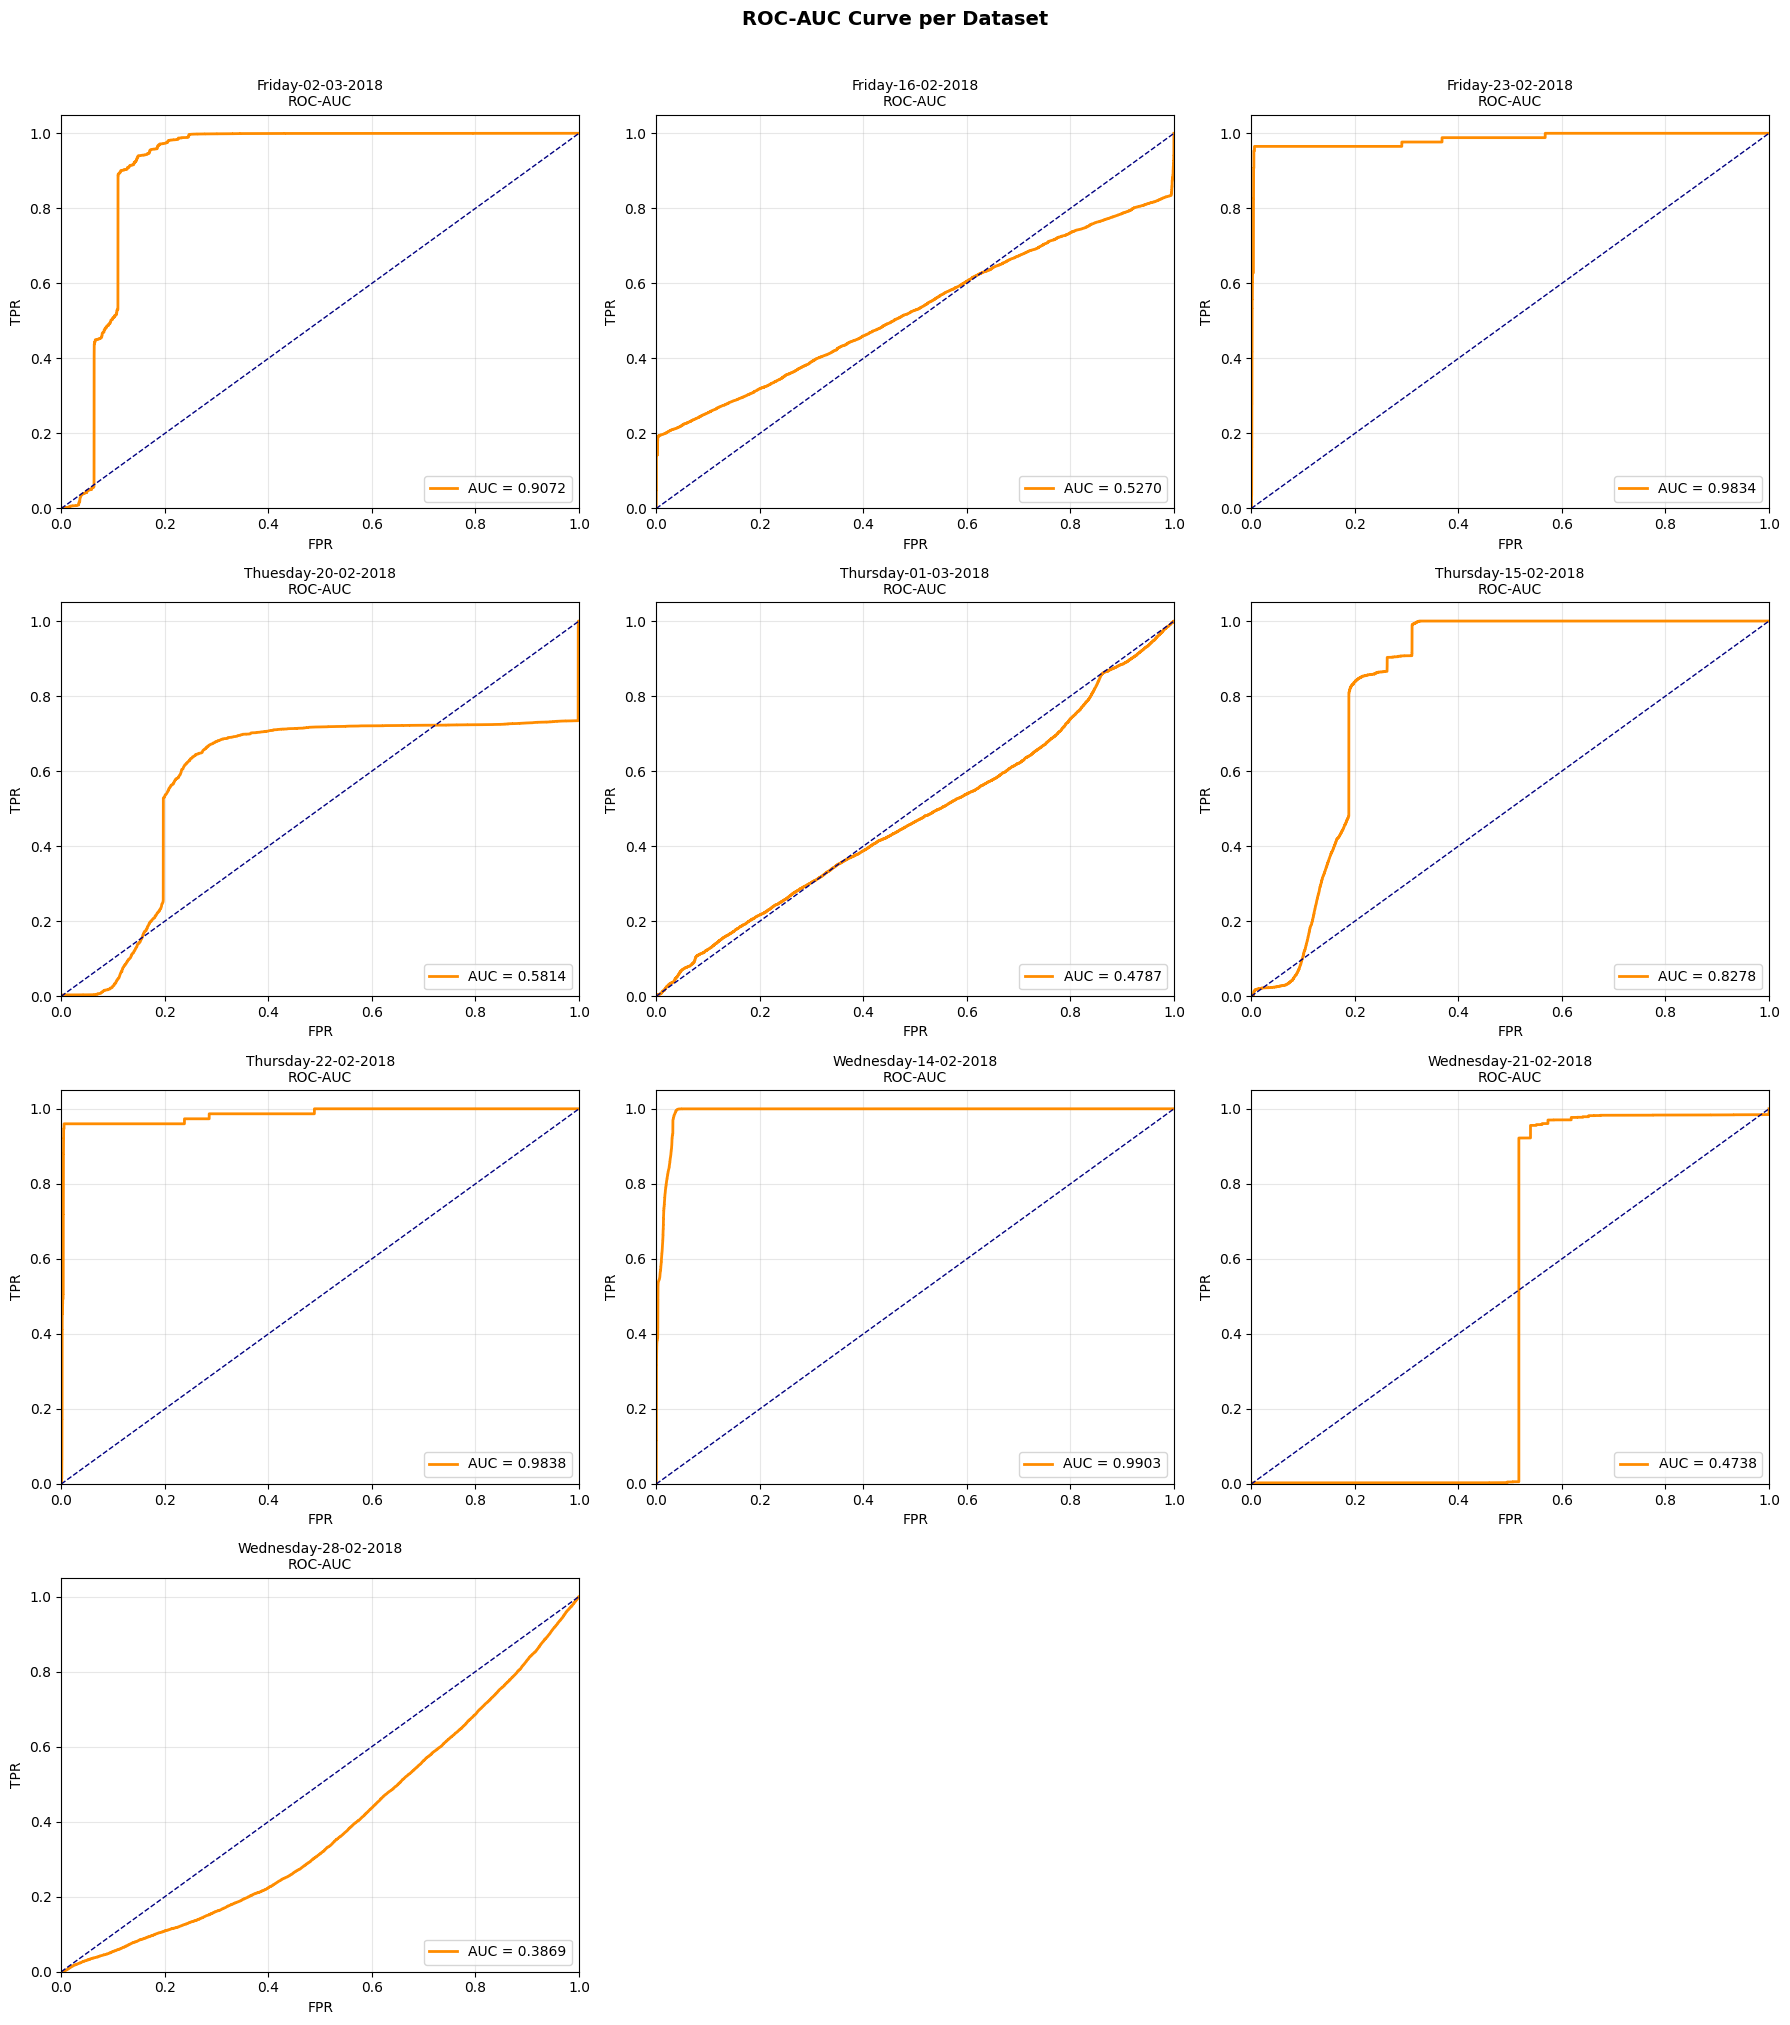

Disimpan ke roc_curves_all_datasets.png


In [10]:
valid_results = [r for r in results if not r["skipped"]]
n = len(valid_results)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = axes.flatten() if n > 1 else [axes]

for i, r in enumerate(valid_results):
    ax = axes[i]
    short_name = r["filename"].replace("_TrafficForML_CICFlowMeter.csv", "")
    ax.plot(r["fpr"], r["tpr"], color="darkorange", linewidth=2,
            label=f"AUC = {r['roc_auc']:.4f}")
    ax.plot([0, 1], [0, 1], color="navy", linewidth=1, linestyle="--")
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title(f"{short_name}\nROC-AUC", fontsize=10)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)

# Sembunyikan subplot kosong
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("ROC-AUC Curve per Dataset", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("roc_curves_all_datasets.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan ke roc_curves_all_datasets.png")

## 8. Grafik Precision-Recall Curve per Dataset

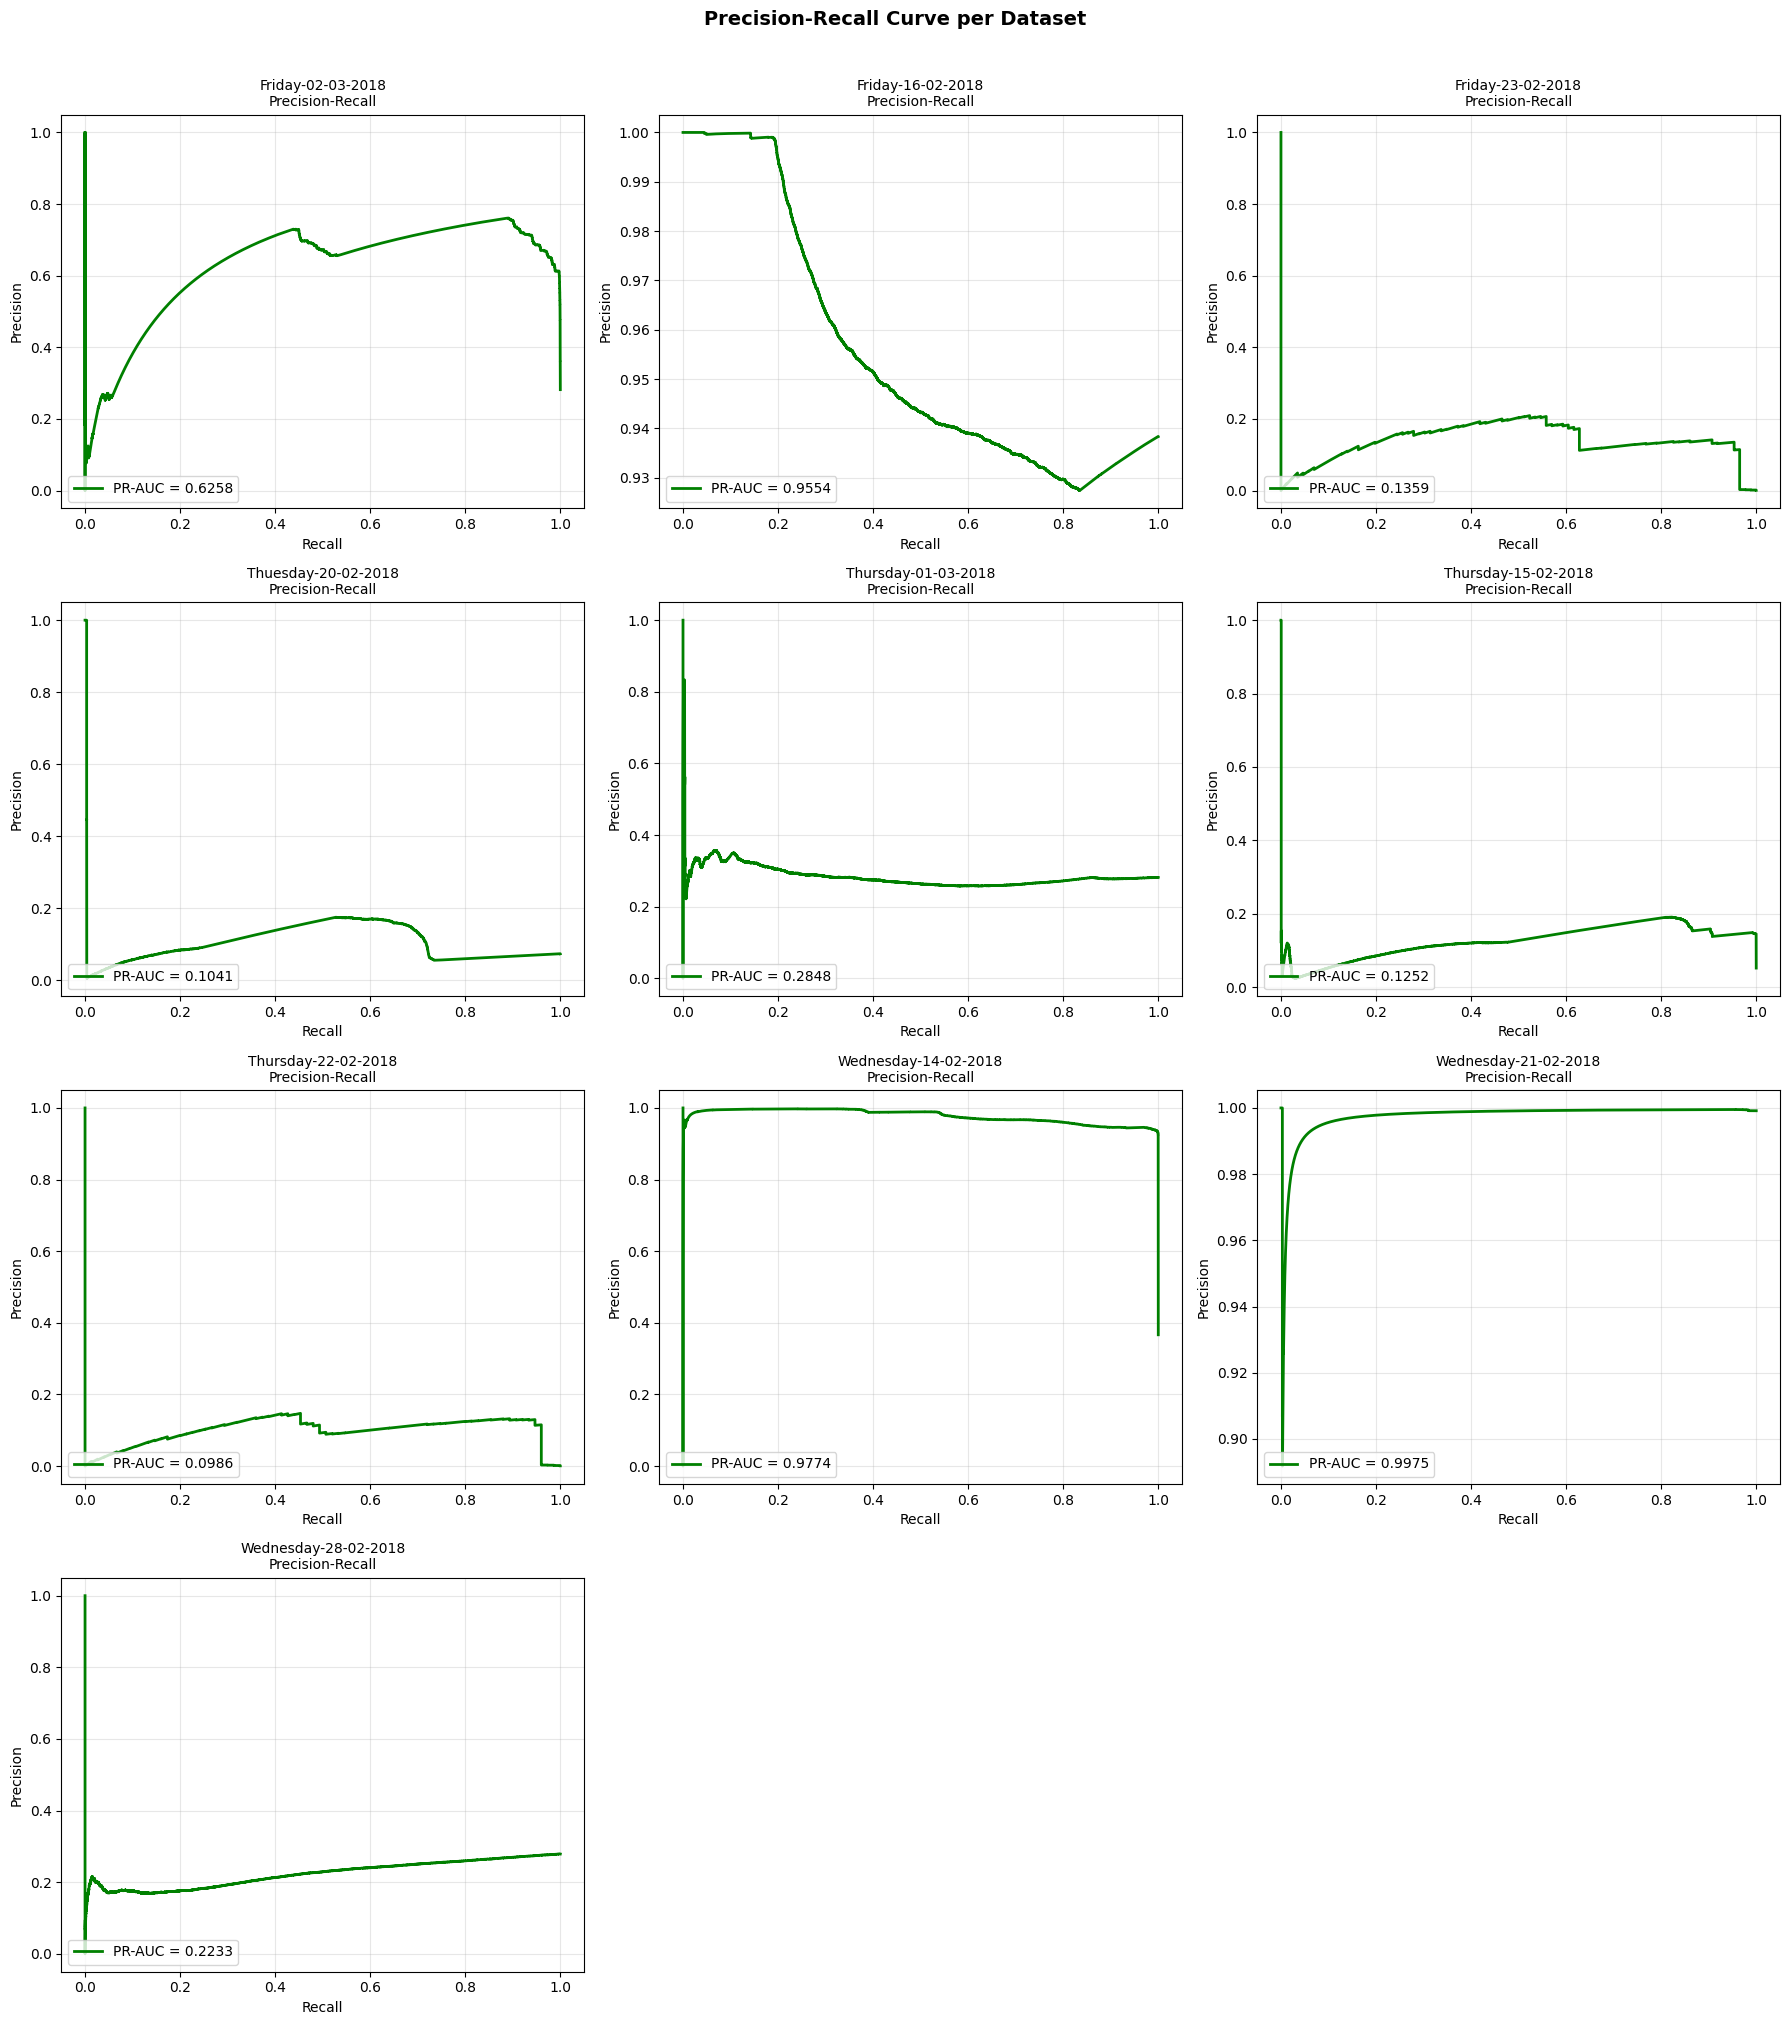

Disimpan ke pr_curves_all_datasets.png


In [11]:
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
axes = axes.flatten() if n > 1 else [axes]

for i, r in enumerate(valid_results):
    ax = axes[i]
    short_name = r["filename"].replace("_TrafficForML_CICFlowMeter.csv", "")
    ax.plot(r["rec_curve"], r["prec_curve"], color="green", linewidth=2,
            label=f"PR-AUC = {r['pr_auc']:.4f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{short_name}\nPrecision-Recall", fontsize=10)
    ax.legend(loc="lower left")
    ax.grid(True, alpha=0.3)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Precision-Recall Curve per Dataset", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("pr_curves_all_datasets.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan ke pr_curves_all_datasets.png")

## 9. Bar Chart: Perbandingan Metrik Antar Dataset

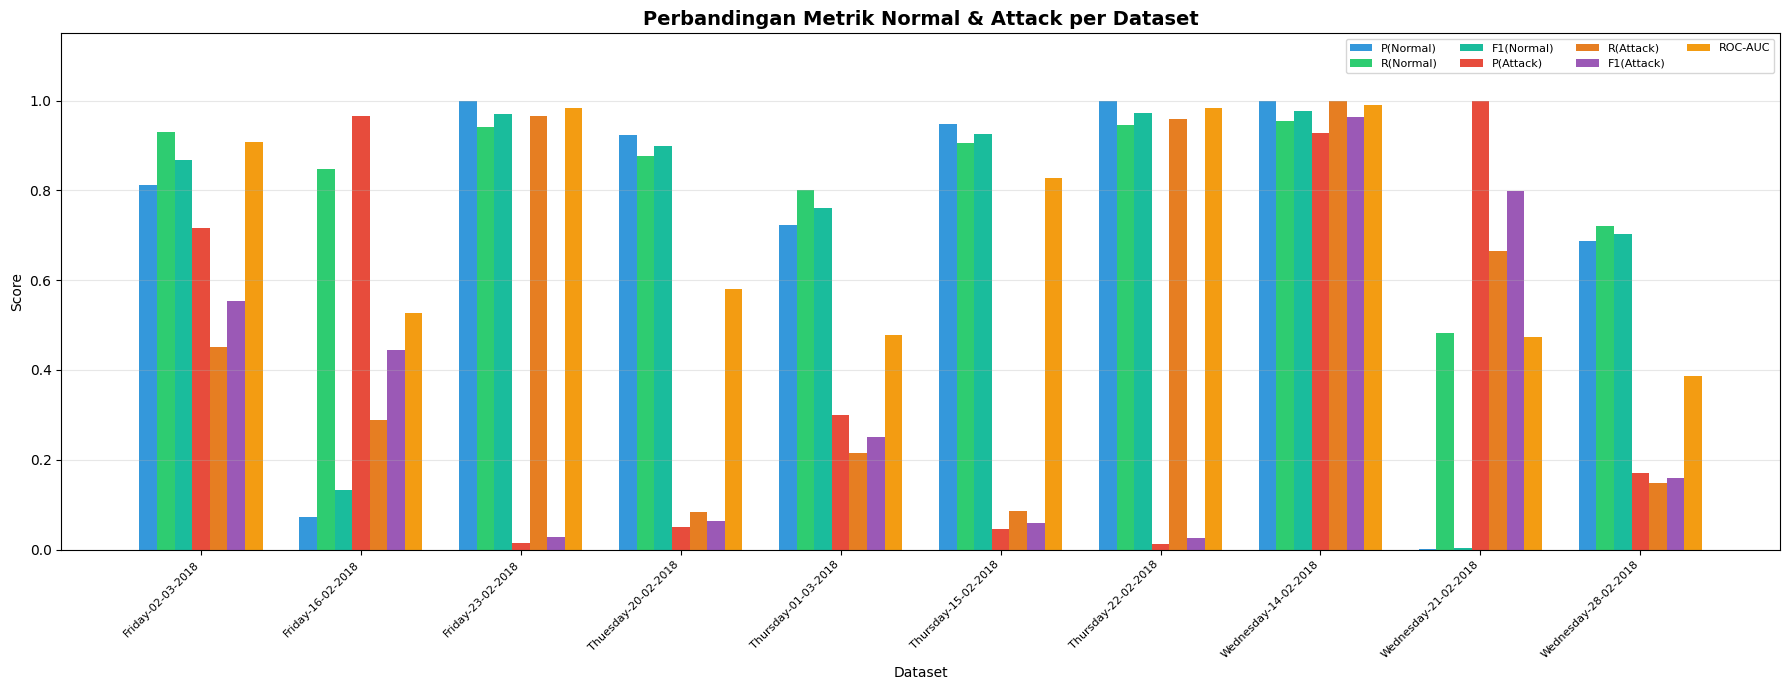

Disimpan ke metrics_comparison_all_datasets.png


In [12]:
file_names = [r["filename"].replace("_TrafficForML_CICFlowMeter.csv", "")
              for r in valid_results]

p_normal = [r["precision_normal"] for r in valid_results]
r_normal = [r["recall_normal"] for r in valid_results]
f1_normal = [r["f1_normal"] for r in valid_results]
p_attack = [r["precision_attack"] for r in valid_results]
r_attack = [r["recall_attack"] for r in valid_results]
f1_attack = [r["f1_attack"] for r in valid_results]
roc_aucs = [r["roc_auc"] for r in valid_results]

x = np.arange(len(file_names))
width = 0.11

fig, ax = plt.subplots(figsize=(18, 7))

ax.bar(x - 3 * width, p_normal, width, label="P(Normal)", color="#3498db")
ax.bar(x - 2 * width, r_normal, width, label="R(Normal)", color="#2ecc71")
ax.bar(x - 1 * width, f1_normal, width, label="F1(Normal)", color="#1abc9c")
ax.bar(x, p_attack, width, label="P(Attack)", color="#e74c3c")
ax.bar(x + 1 * width, r_attack, width, label="R(Attack)", color="#e67e22")
ax.bar(x + 2 * width, f1_attack, width, label="F1(Attack)", color="#9b59b6")
ax.bar(x + 3 * width, roc_aucs, width, label="ROC-AUC", color="#f39c12")

ax.set_xlabel("Dataset")
ax.set_ylabel("Score")
ax.set_title("Perbandingan Metrik Normal & Attack per Dataset", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(file_names, rotation=45, ha="right", fontsize=8)
ax.set_ylim([0, 1.15])
ax.legend(loc="upper right", fontsize=8, ncol=4)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("metrics_comparison_all_datasets.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan ke metrics_comparison_all_datasets.png")

## 10. Confusion Matrix per Dataset

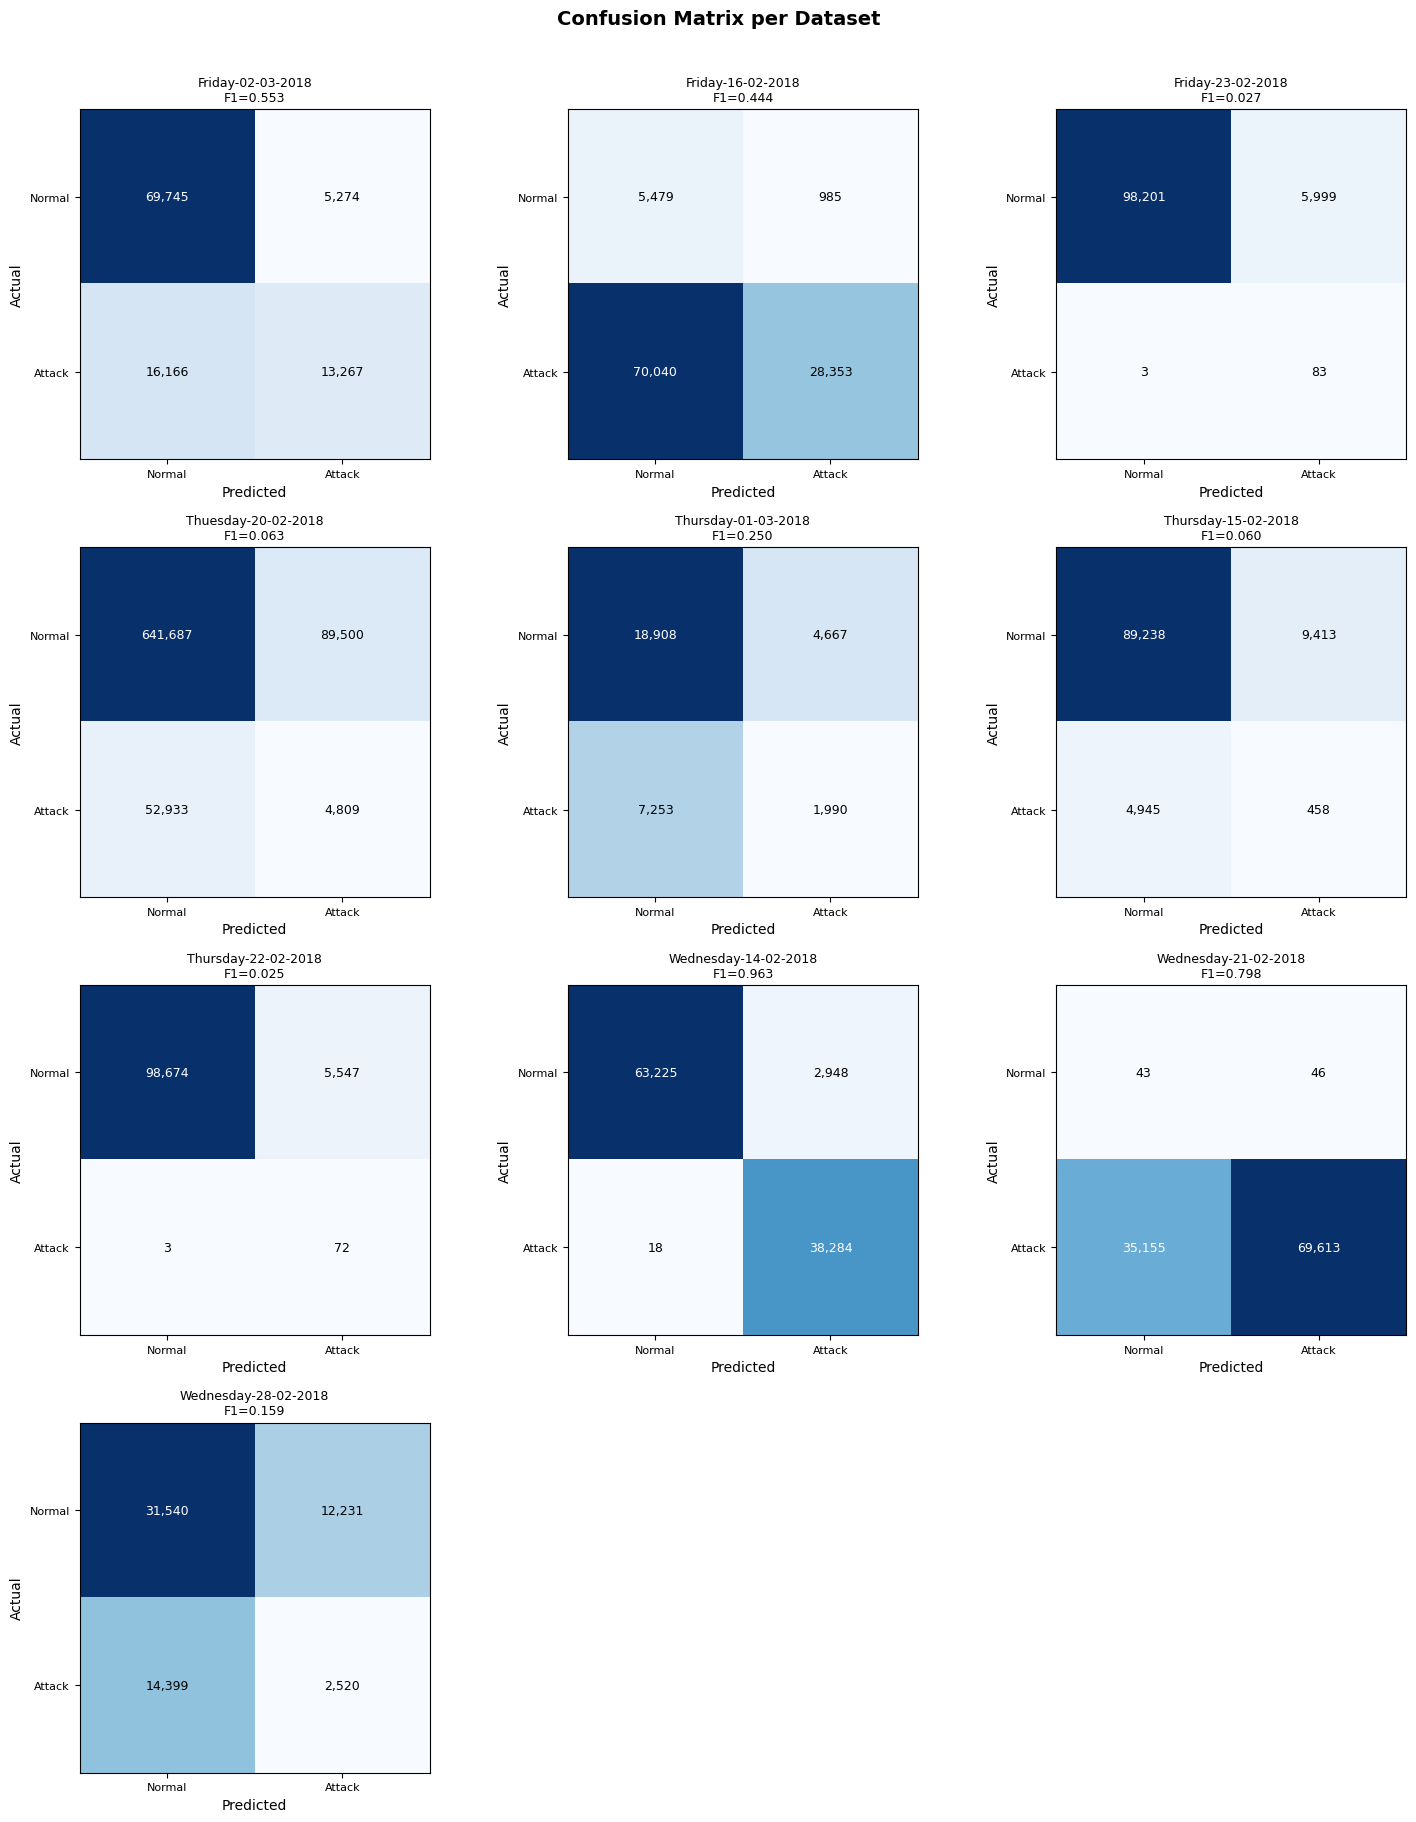

Disimpan ke confusion_matrices_all_datasets.png


In [13]:
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.5 * rows))
axes = axes.flatten() if n > 1 else [axes]

for i, r in enumerate(valid_results):
    ax = axes[i]
    short_name = r["filename"].replace("_TrafficForML_CICFlowMeter.csv", "")
    cm = r["confusion_matrix"]
    im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.set_title(f"{short_name}\nF1={r['f1']:.3f}", fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Normal", "Attack"], fontsize=8)
    ax.set_yticklabels(["Normal", "Attack"], fontsize=8)
    for a in range(2):
        for b in range(2):
            ax.text(b, a, f"{cm[a, b]:,}", ha="center", va="center",
                    color="white" if cm[a, b] > cm.max() / 2 else "black", fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrix per Dataset", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("confusion_matrices_all_datasets.png", dpi=150, bbox_inches="tight")
plt.show()
print("Disimpan ke confusion_matrices_all_datasets.png")

## 11. Ringkasan Akhir

In [14]:
valid = [r for r in results if not r["skipped"]]

avg_pn = np.mean([r["precision_normal"] for r in valid])
avg_rn = np.mean([r["recall_normal"] for r in valid])
avg_fn = np.mean([r["f1_normal"] for r in valid])
avg_pa = np.mean([r["precision_attack"] for r in valid])
avg_ra = np.mean([r["recall_attack"] for r in valid])
avg_fa = np.mean([r["f1_attack"] for r in valid])
avg_roc = np.mean([r["roc_auc"] for r in valid])
avg_pr = np.mean([r["pr_auc"] for r in valid])

print("=" * 70)
print("RINGKASAN EVALUASI LSTM-AUTOENCODER PADA 10 DATASET")
print("=" * 70)
print(f"Model:             LSTM-Autoencoder (PyTorch)")
print(f"Checkpoint:        {CHECKPOINT_PATH}")
print(f"Threshold:         {THRESHOLD:.6f}")
print(f"Fitur:             {len(FEATURE_COLUMNS)} kolom")
print(f"Sequence Length:   {SEQ_LEN}")
print(f"File dievaluasi:   {len(csv_files)}")
print(f"File valid:        {len(valid)}")
print(f"File skipped:      {len(csv_files) - len(valid)}")

print(f"\n--- Rata-rata Metrik ({len(valid)} file) ---")
print(f"  {'Kelas':<10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print(f"  {'-'*42}")
print(f"  {'Normal':<10} {avg_pn:>10.4f} {avg_rn:>10.4f} {avg_fn:>10.4f}")
print(f"  {'Attack':<10} {avg_pa:>10.4f} {avg_ra:>10.4f} {avg_fa:>10.4f}")
print(f"\n  ROC-AUC:   {avg_roc:.4f}")
print(f"  PR-AUC:    {avg_pr:.4f}")
print("=" * 70)

# Detail per file
print(f"\n--- Detail per File ---")
for r in results:
    name = r["filename"].replace("_TrafficForML_CICFlowMeter.csv", "")
    if r["skipped"]:
        print(f"  {name:<35} SKIPPED ({r['reason']})")
    else:
        attacks = [k for k, v in r["label_detail"].items() if k != "Benign"]
        print(f"  {name:<35} F1(N)={r['f1_normal']:.4f}  F1(A)={r['f1_attack']:.4f}  ROC={r['roc_auc']:.4f}  Attacks: {', '.join(attacks)}")

RINGKASAN EVALUASI LSTM-AUTOENCODER PADA 10 DATASET
Model:             LSTM-Autoencoder (PyTorch)
Checkpoint:        lstm_autoencoder_checkpoint.pth
Threshold:         0.527213
Fitur:             10 kolom
Sequence Length:   10
File dievaluasi:   10
File valid:        10
File skipped:      0

--- Rata-rata Metrik (10 file) ---
  Kelas       Precision     Recall   F1-Score
  ------------------------------------------
  Normal         0.7166     0.8410     0.7212
  Attack         0.4203     0.4860     0.3343

  ROC-AUC:   0.7140
  PR-AUC:    0.4528

--- Detail per File ---
  Friday-02-03-2018                   F1(N)=0.8668  F1(A)=0.5531  ROC=0.9072  Attacks: Bot
  Friday-16-02-2018                   F1(N)=0.1337  F1(A)=0.4439  ROC=0.5270  Attacks: DoS attacks-Hulk, DoS attacks-SlowHTTPTest
  Friday-23-02-2018                   F1(N)=0.9703  F1(A)=0.0269  ROC=0.9834  Attacks: Brute Force -Web, Brute Force -XSS, SQL Injection
  Thuesday-20-02-2018                 F1(N)=0.9001  F1(A)=0.0633 